<a href="https://colab.research.google.com/github/fadeeva/Risk_Alpha_Stable/blob/main/notebooks/Calibration_of_the_alpha-stable_dist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
from collections import defaultdict

import numpy as np
import pandas as pd

from scipy import stats
from scipy.stats import levy_stable
from scipy.optimize import minimize_scalar

import matplotlib.pyplot as plt
plt.style.use('ggplot')

# Calibration of the alpha-stable distribution

## Data

In [2]:
url = 'https://github.com/fadeeva/Risk_Alpha_Stable/raw/refs/heads/main/data/'

data = {
    'btc-usd': pd.read_csv(f'{url}btc-usd.csv', parse_dates=True, index_col=0, header=[0, 1]),
    'gold': pd.read_csv(f'{url}gold.csv', parse_dates=True, index_col=0, header=[0, 1]),
    'spy' : pd.read_csv(f'{url}spy.csv', parse_dates=True, index_col=0, header=[0, 1]),
    'tlt': pd.read_csv(f'{url}tlt.csv', parse_dates=True, index_col=0, header=[0, 1]),
    'usdrub': pd.read_csv(f'{url}usdrub.csv', parse_dates=True, index_col=0, header=[0, 1]),
}

for ticker in data.keys():
    data[ticker]['log_return'] = np.log(data[ticker]['Close'].div(data[ticker]['Close'].shift(1)))
    data[ticker].dropna(axis=0, inplace=True)


## Finding $\alpha$

### Quantile Matching

In [40]:
def loss(alpha, returns, quantiles=[1, 5, 10, 25, 50, 75, 90, 95, 99], N=10_000):
    sample = levy_stable.rvs(alpha, beta=0, size=N)

    quantiles_model = np.percentile(sample, quantiles)
    quantiles_returns = np.percentile(returns, quantiles)

    return np.sum((quantiles_returns - quantiles_model)**2)


In [41]:
alphas = np.linspace(0.5, 2.0, 20)

losses = defaultdict(list)

for alpha in alphas:
    for ticker, asset in data.items():
        losses[ticker].append(loss(alpha, asset['log_return']))

optimal_alphas = defaultdict(list)
for ticker, asset in data.items():
    optimal_alphas[ticker].append(minimize_scalar(lambda a: loss(a, asset['log_return']), bounds=(0.5, 2.0), method='bounded'))

losses.keys(), optimal_alphas.keys()

(dict_keys(['btc-usd', 'gold', 'spy', 'tlt', 'usdrub']),
 dict_keys(['btc-usd', 'gold', 'spy', 'tlt', 'usdrub']))

In [44]:
optimal_alphas['btc-usd']

[ message: Solution found.
  success: True
   status: 0
      fun: 40.28129904623982
        x: 1.961062358916917
      nit: 23
     nfev: 23]

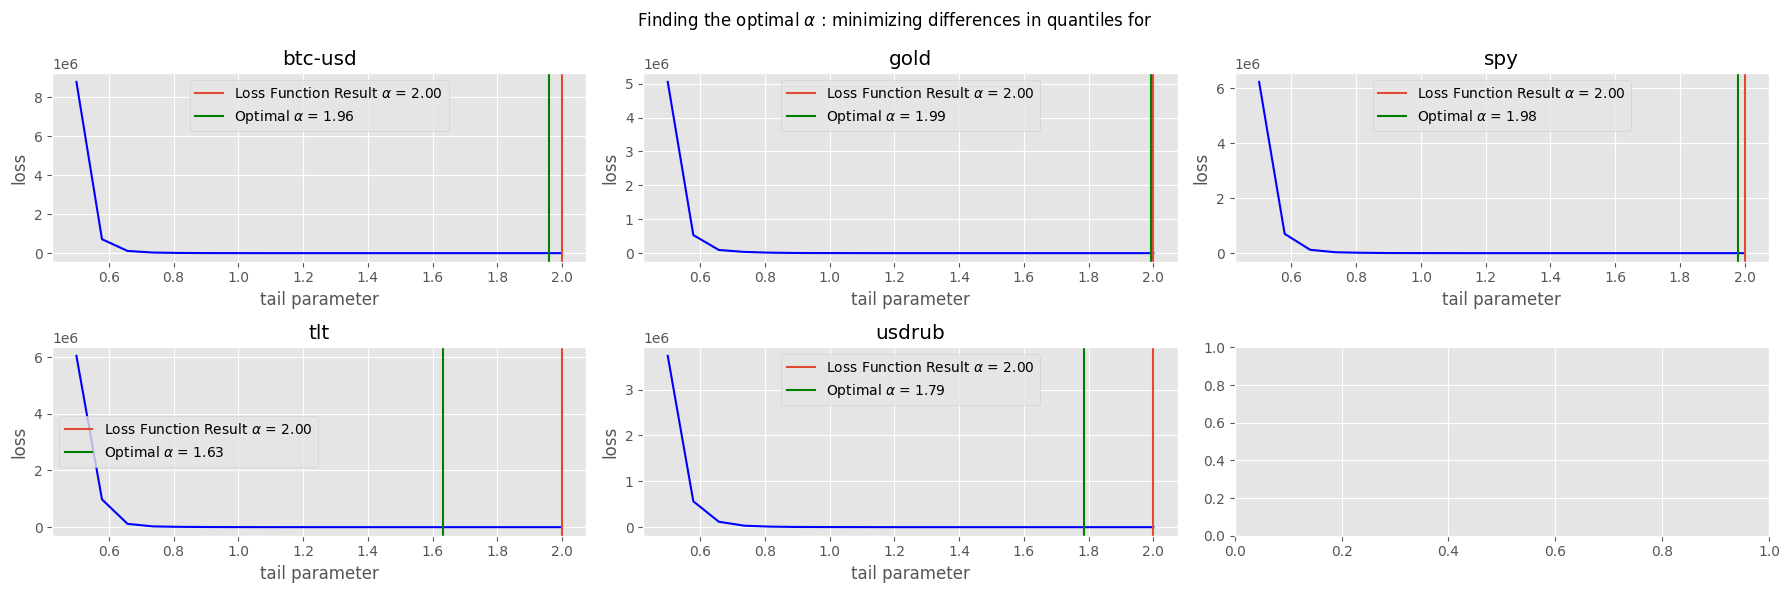

In [43]:
fig, axes = plt.subplots(2, 3, figsize=(18, 6))
axes = axes.flatten()

for i, (ticker, l) in enumerate(losses.items()):
    axes[i].plot(alphas, l, c='b')
    axes[i].axvline(x=alphas[np.argmin(l)],
                    label='Loss Function Result ' + r'$\alpha$ = ' + f'{alphas[np.argmin(l)]:.2f}')
    axes[i].axvline(x=optimal_alphas[ticker][0].x, color='g',
                    label='Optimal ' + r'$\alpha$ = ' + f'{optimal_alphas[ticker][0].x:.2f}')
    axes[i].set_xlabel('tail parameter')
    axes[i].set_ylabel('loss')

    axes[i].set_title(f'{ticker}')
    axes[i].legend()

plt.suptitle(r'Finding the optimal $\alpha$ : minimizing differences in quantiles for')
plt.tight_layout();